In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
sns.set_theme(style="whitegrid")
from pathlib import Path

def to_num(s):
    return pd.to_numeric(s.astype(str).str.replace(",", "", regex=False), errors="coerce")

In [40]:
# unos_trans = pd.read_csv("unos_transplant.csv")
# unos_waitlist = pd.read_csv("uno_waitlist.csv")
# cdc_mort = pd.read_csv("CDC_MORTALITY_cleaned_joined_long.csv")
# census = pd.read_csv("census.csv")
# wait = pd.read_csv("Organ_by_Waiting_Time.csv")
# wait_comb = pd.read_csv("Can+Reg_Organ_by_Waiting_Time.csv")

In [4]:
unos_trans = pd.read_csv("unos_transplant.csv")
unos_trans.head()

,Year,All Recipient Ages,< 1 Year,1-5 Years,6-10 Years,11-17 Years,18-34 Years,35-49 Years,50-64 Years,65,...,Female,All_race,White,Black,Hispanic/Latino,Unknown.1,Asian,"American Indian/Alaska Native, Non-Hispanic","Pacific Islander, Non-Hispanic","Multiracial, Non-Hispanic"
0,To Date,1068934,10171,18090,10810,27276,139441,282734,418755,161642,...,409276,1068934,638199,211736,152128,1852,49113,7817,3518,4571
1,2026,4002,13,33,27,47,349,884,1580,1069,...,1590,4002,1950,890,772,73,233,32,17,35
2,2025,49065,243,494,302,835,4360,10800,19487,12544,...,19208,49065,24136,10864,9329,872,2890,379,215,380
3,2024,48150,254,521,311,887,4320,10550,19295,12012,...,18798,48150,23642,10992,9102,632,2815,391,189,387
4,2023,46634,253,510,344,809,4427,10280,18907,11104,...,18084,46634,23473,10830,8542,77,2792,368,176,376


In [6]:
cdc_mort = pd.read_csv("CDC_MORTALITY_cleaned_joined_long.csv")
cdc_mort.head()

,breakdown,category,category_code,Deaths,Population,Crude Rate,Lower CI,Upper CI,Year,is_total
0,Age Groups,< 1 year,1,"142,638.00","25,878,128.00",551.2,548.3,554.1,NaN,False
1,Age Groups,1-4 years,1 - 4.,"26,909.00","107,286,287.00",25.1,24.8,25.4,NaN,False
2,Age Groups,5-14 years,5 - 14.,"40,729.00","287,785,979.00",14.2,14.0,14.3,NaN,False
3,Age Groups,15-24 years,15-24.,"232,944.00","304,328,641.00",76.5,76.2,76.9,NaN,False
4,Age Groups,25-34 years,25-34.,"473,427.00","320,700,526.00",147.6,147.2,148.0,NaN,False


In [7]:
census = pd.read_csv("census_cleaned.csv")
census.head()

,geo_id,name,fip_county,state_fip,tot_pop,male_est,female_est,under_18_years,16_years_and_over,18_years_and_over,...,race_hispanic,other_race,median_income,poverty_rate,uninsured_rate,geo_fips5_extracted,geo_state_fips_2_extracted,state_fips_2,poverty_col_share_of_totpop,uninsured_col_share_of_totpop
0,0400000US01001,Alabama,1,1001,5157699,2490551,2667148,1132203,4160138,4025496,...,5157699,128575,63999,4666970,640276,1001,1,1,0.904855,0.124140
1,0400000US01002,Alaska,2,1002,740133,390301,349832,174198,586083,565935,...,740133,15526,92788,696822,134276,1002,1,2,0.941482,0.181421
2,0400000US01004,Arizona,4,1004,7582384,3782883,3799501,1585751,6193806,5996633,...,7582384,707919,79964,6272686,1050638,1004,1,4,0.827271,0.138563
3,0400000US01005,Arkansas,5,1005,3088354,1517526,1570828,698141,2477205,2390213,...,3088354,96607,60773,2839798,455936,1005,1,5,0.919518,0.147631
4,0400000US01006,California,6,1006,39431263,19675103,19756160,8411338,32089744,31019925,...,39431263,7433192,99122,36593372,6267799,1006,1,6,0.928029,0.158955


In [38]:
wait_comb = pd.read_csv("Can+Reg_Organ_by_Waiting_Time.csv")
wait_comb.head()

,Cand+Reg,Waiting_Time,< 30 Days,30 to < 90 Days,90 Days to < 6 Months,6 Months to < 1 Year,1 Year to < 2 Years,2 Years to < 3 Years,3 Years to < 5 Years,5 or More Years
0,All Organs,229027,11782,16530,27192,41671,51909,32950,32435,21061
1,Kidney,197272,8391,12860,22119,35308,45646,29883,29993,19165
2,Liver,17873,2034,2150,3098,3656,3206,1550,1215,1051
3,Pancreas,1639,61,95,160,253,422,220,208,224
4,Kidney / Pancreas,4823,254,418,634,1042,1330,649,411,161


UNOS transplants by year (demographics)

In [75]:
tx = pd.read_csv("unos_transplant.csv", dtype=str)
tx.columns = tx.columns.str.strip()

# drop "To Date"
tx = tx[tx["Year"].astype(str).str.fullmatch(r"\d{4}", na=False)].copy()
tx["Year"] = pd.to_numeric(tx["Year"], errors="coerce").astype("Int64")

for c in tx.columns:
    if c != "Year":
        tx[c] = to_num(tx[c])

UNOS waitlist snapshot (wide with state columns)

In [76]:
wl = pd.read_csv("uno_waitlist.csv", dtype=str)
wl.columns = wl.columns.str.strip()
wl["Candidates"] = wl["Candidates"].astype(str).str.strip()

# convert core demographic columns to numeric (if present)
demo_cols = ["All Genders","Male","Female","All Ages","All_Race","White","Black","Hispanic","Asian"]
for c in demo_cols:
    if c in wl.columns:
        wl[c] = to_num(wl[c])

Wait-time bins (Candidates + Registrations)

In [44]:
wt = pd.read_csv("Can+Reg_Organ_by_Waiting_Time.csv", dtype=str)
wt.columns = wt.columns.str.strip()
wt = wt.rename(columns={"Cand+Reg":"organ"})
wt["organ"] = wt["organ"].astype(str).str.strip()

bins = ["< 30 Days","30 to < 90 Days","90 Days to < 6 Months","6 Months to < 1 Year",
        "1 Year to < 2 Years","2 Years to < 3 Years","3 Years to < 5 Years","5 or More Years"]

for b in bins:
    wt[b] = to_num(wt[b])

wt["total_waiting"] = wt[bins].sum(axis=1)

midpoints = {
    "< 30 Days": 15,
    "30 to < 90 Days": 60,
    "90 Days to < 6 Months": 135,
    "6 Months to < 1 Year": 270,
    "1 Year to < 2 Years": 547.5,
    "2 Years to < 3 Years": 912.5,
    "3 Years to < 5 Years": 1460,
    "5 or More Years": 2190,   # assumption (~6 years)
}

wt["est_mean_wait_days"] = sum(wt[b]*midpoints[b] for b in bins) / wt["total_waiting"]
wt["pct_wait_1y_plus"] = (wt["1 Year to < 2 Years"] + wt["2 Years to < 3 Years"] +
                          wt["3 Years to < 5 Years"] + wt["5 or More Years"]) / wt["total_waiting"]
wt["pct_wait_5y_plus"] = wt["5 or More Years"] / wt["total_waiting"]

Census state context

In [46]:
census = pd.read_csv("census_cleaned.csv", dtype=str)
census.columns = census.columns.str.strip().str.lower()

for c in ["tot_pop","median_income","poverty_rate","uninsured_rate"]:
    if c in census.columns:
        census[c] = to_num(census[c])

# if poverty_rate/uninsured_rate are counts, convert to shares
census["poverty_share"] = census["poverty_rate"] / census["tot_pop"]
census["uninsured_share"] = census["uninsured_rate"] / census["tot_pop"]

CDC mortality (state crude rate + year crude rate)

In [48]:
cdc = pd.read_csv("CDC_MORTALITY_cleaned_joined_long.csv", dtype=str)

# standardize headers
cdc.columns = (cdc.columns.str.strip()
               .str.lower()
               .str.replace(r"[^a-z0-9]+","_", regex=True))

# numeric conversion (the file may contain death/pop as strings with commas)
for c in ["deaths", "population", "crude_rate"]:
    if c in cdc.columns:
        cdc[c] = to_num(cdc[c])

Supporting Question 1
Do transplant rates differ by race/ethnicity/sex/age?

Race shares over time (line chart)

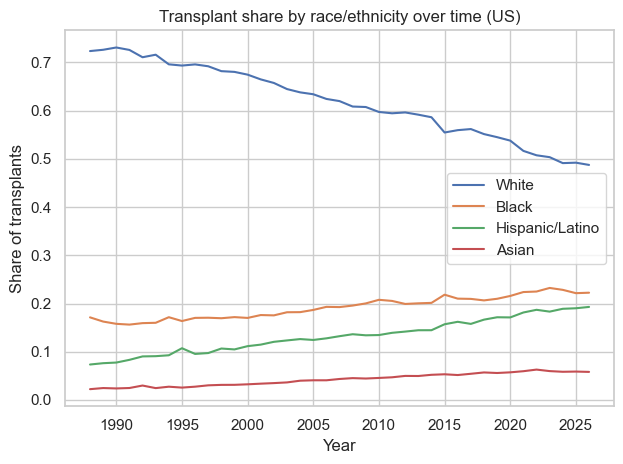

In [49]:
race_cols = ["White","Black","Hispanic/Latino","Asian"]
race_cols = [c for c in race_cols if c in tx.columns]

tx_race = tx[["Year","All Recipient Ages"] + race_cols].copy()
for c in ["All Recipient Ages"] + race_cols:
    tx_race[c] = to_num(tx_race[c])

for c in race_cols:
    tx_race[c+"_share"] = tx_race[c] / tx_race["All Recipient Ages"]

plt.figure()
for c in race_cols:
    plt.plot(tx_race["Year"], tx_race[c+"_share"], label=c)
plt.title("Transplant share by race/ethnicity over time (US)")
plt.xlabel("Year"); plt.ylabel("Share of transplants")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
Sex counts (latest year bar chart)

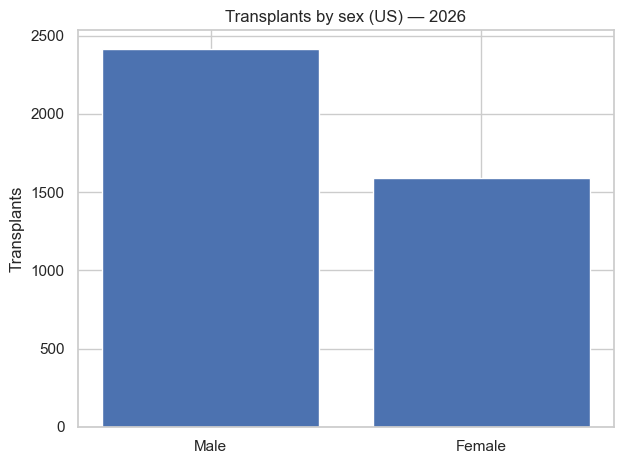

In [50]:
latest = tx["Year"].max()
row = tx.loc[tx["Year"] == latest].iloc[0]

sex_cols = [c for c in ["Male","Female"] if c in tx.columns]
sex_counts = pd.Series({c: row[c] for c in sex_cols}).astype(float)

plt.figure()
plt.bar(sex_counts.index, sex_counts.values)
plt.title(f"Transplants by sex (US) — {latest}")
plt.ylabel("Transplants")
plt.tight_layout()
plt.show()

Extra equity insight (optional): compare waitlist race share vs transplant race share

In [51]:
# waitlist snapshot (All Organs row)
wl_all = wl[wl["Candidates"].eq("All Organs")].iloc[0]
wait_race_cols = [c for c in ["White","Black","Hispanic","Asian"] if c in wl.columns]
wl_race = pd.Series({c: float(wl_all[c]) for c in wait_race_cols})
wl_race_share = wl_race / wl_race.sum()

# transplant race share (latest year)
tx_race_share_latest = (pd.Series({c: float(row[c]) for c in race_cols}) /
                        float(row["All Recipient Ages"]))

compare = pd.DataFrame({
    "waitlist_share": wl_race_share,
    "transplant_share": tx_race_share_latest.reindex(wl_race_share.index)
})

compare.plot(kind="bar")
plt.title(f"Waitlist share vs Transplant share (snapshot vs {latest})")
plt.ylabel("Share")
plt.tight_layout()
plt.show()

IndexError: single positional indexer is out-of-bounds

Wait time differences by organ (bar charts)

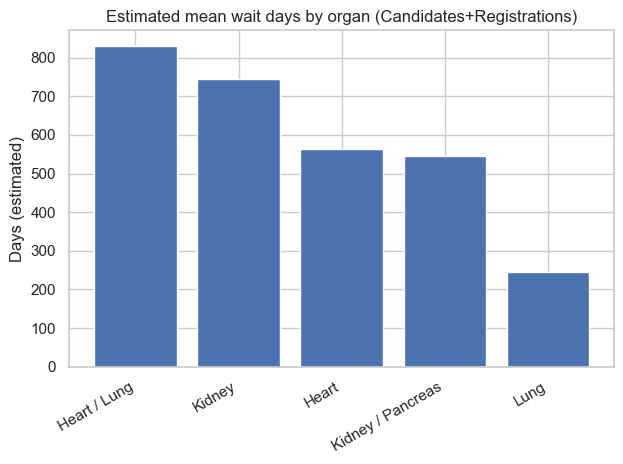

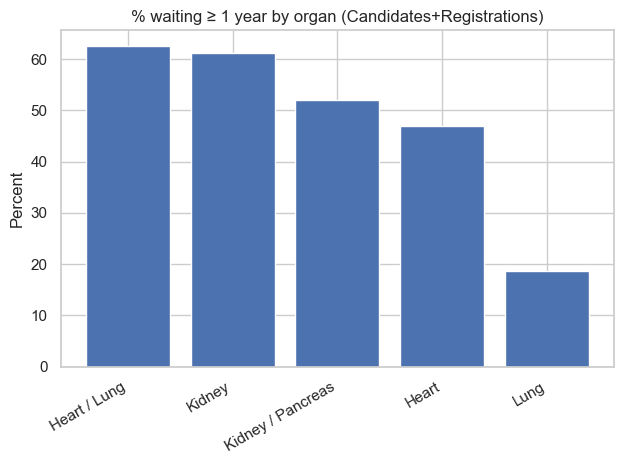

In [52]:
focus_orgs = ["Heart","Kidney","Lung"]
sub = wt[wt["organ"].str.contains("|".join(focus_orgs), case=False, na=False)].copy()

# Estimated mean wait days
plot = sub.sort_values("est_mean_wait_days", ascending=False)
plt.figure()
plt.bar(plot["organ"], plot["est_mean_wait_days"])
plt.title("Estimated mean wait days by organ (Candidates+Registrations)")
plt.ylabel("Days (estimated)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# % waiting >= 1 year
plot = sub.sort_values("pct_wait_1y_plus", ascending=False)
plt.figure()
plt.bar(plot["organ"], plot["pct_wait_1y_plus"]*100)
plt.title("% waiting ≥ 1 year by organ (Candidates+Registrations)")
plt.ylabel("Percent")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Geographic differences: waitlist burden per 100k by state (Kidney/Heart/Lung)

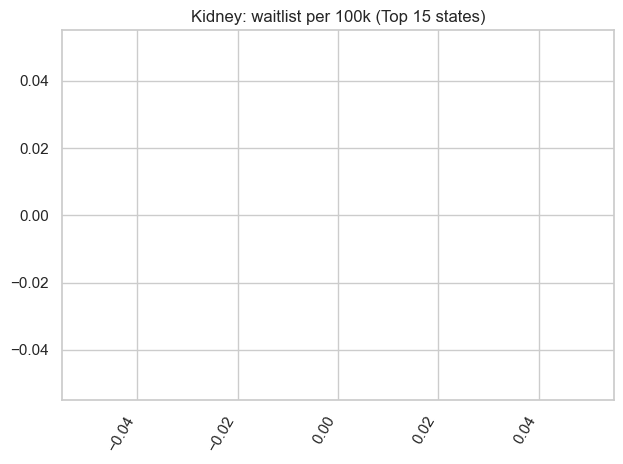

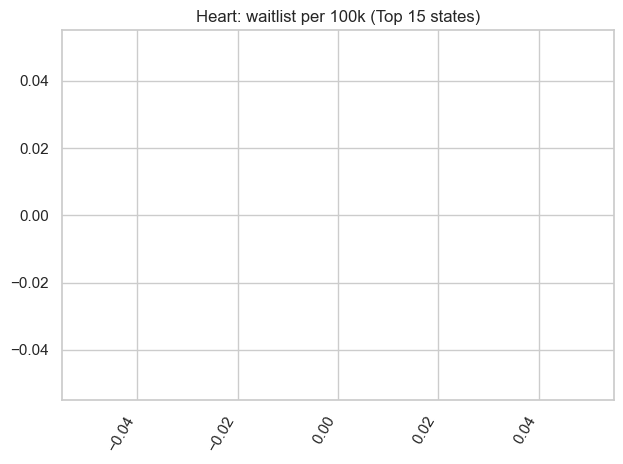

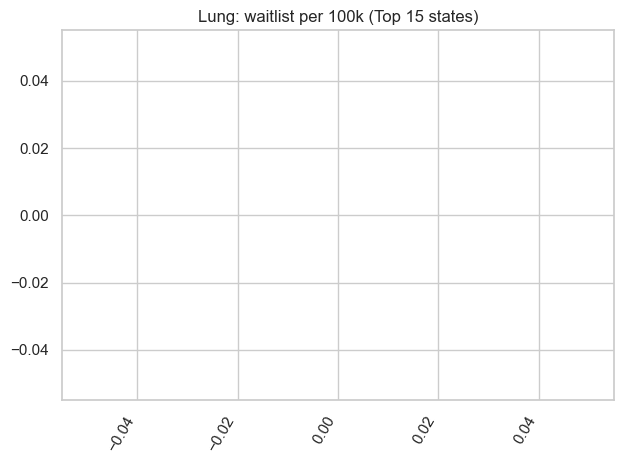

In [56]:
# Detect state columns by using a known set of states
US_STATES = {
    "Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut","Delaware",
    "District of Columbia","Florida","Georgia","Hawaii","Idaho","Illinois","Indiana","Iowa",
    "Kansas","Kentucky","Louisiana","Maine","Maryland","Massachusetts","Michigan","Minnesota",
    "Mississippi","Missouri","Montana","Nebraska","Nevada","New Hampshire","New Jersey",
    "New Mexico","New York","North Carolina","North Dakota","Ohio","Oklahoma","Oregon",
    "Pennsylvania","Rhode Island","South Carolina","South Dakota","Tennessee","Texas","Utah",
    "Vermont","Virginia","Washington","West Virginia","Wisconsin","Wyoming","Puerto Rico"
}
state_cols = [c for c in wl.columns if c in US_STATES]

wl_state = wl[["Candidates"] + state_cols].copy()
for c in state_cols:
    wl_state[c] = to_num(wl_state[c])

wl_state_long = wl_state.melt("Candidates", var_name="state", value_name="waitlist_count") \
                        .rename(columns={"Candidates":"organ"})

master_state = wl_state_long.merge(
    census[["name","tot_pop","median_income","poverty_share","uninsured_share"]],
    left_on="state", right_on="name", how="left"
).drop(columns=["name"])

master_state["waitlist_per_100k"] = (master_state["waitlist_count"] / master_state["tot_pop"]) * 100000

def top15_bar(organ_name):
    sub = master_state[master_state["organ"].str.contains(organ_name, case=False, na=False)].copy()
    sub = sub.dropna(subset=["waitlist_per_100k"]).sort_values("waitlist_per_100k", ascending=False).head(50)
    plt.figure()
    plt.bar(sub["state"], sub["waitlist_per_100k"])
    plt.title(f"{organ_name}: waitlist per 100k (Top 15 states)")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

for organ_name in ["Kidney","Heart","Lung"]:
    top15_bar(organ_name)

In [73]:
# Detect state columns by using a known set of states
US_STATES = {
    "Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut","Delaware",
    "District of Columbia","Florida","Georgia","Hawaii","Idaho","Illinois","Indiana","Iowa",
    "Kansas","Kentucky","Louisiana","Maine","Maryland","Massachusetts","Michigan","Minnesota",
    "Mississippi","Missouri","Montana","Nebraska","Nevada","New Hampshire","New Jersey",
    "New Mexico","New York","North Carolina","North Dakota","Ohio","Oklahoma","Oregon",
    "Pennsylvania","Rhode Island","South Carolina","South Dakota","Tennessee","Texas","Utah",
    "Vermont","Virginia","Washington","West Virginia","Wisconsin","Wyoming","Puerto Rico"
}
state_cols = [c for c in wl.columns if c in US_STATES]

wl_state = wl[["Registration"] + state_cols].copy()
for c in state_cols:
    wl_state[c] = to_num(wl_state[c])

wl_state_long = wl_state.melt("Registration", var_name="state", value_name="waitlist_count") \
                        .rename(columns={"Registration":"organ"})

master_state = wl_state_long.merge(
    census[["name","tot_pop","median_income","poverty_share","uninsured_share"]],
    left_on="state", right_on="name", how="left"
).drop(columns=["name"])

master_state["waitlist_per_100k"] = (master_state["waitlist_count"] / master_state["tot_pop"]) * 100000000

def top15_bar(organ_name):
    sub = master_state[master_state["organ"].str.contains(organ_name, case=False, na=False)].copy()
    sub = sub.dropna(subset=["waitlist_per_100k"]).sort_values("waitlist_per_100k", ascending=False).head(50)
    plt.figure()
    plt.bar(sub["state"], sub["waitlist_per_100k"])
    plt.title(f"{organ_name}: waitlist per 100k (Top 15 states)")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

for organ_name in ["Kidney","Heart","Lung"]:
    top15_bar(organ_name)

KeyError: "None of [Index(['Registration'], dtype='object')] are in the [columns]"

Supporting Question 3
How does insurance status or region relate to likelihood of receiving a transplant?

Scatter: uninsured share vs waitlist per 100k

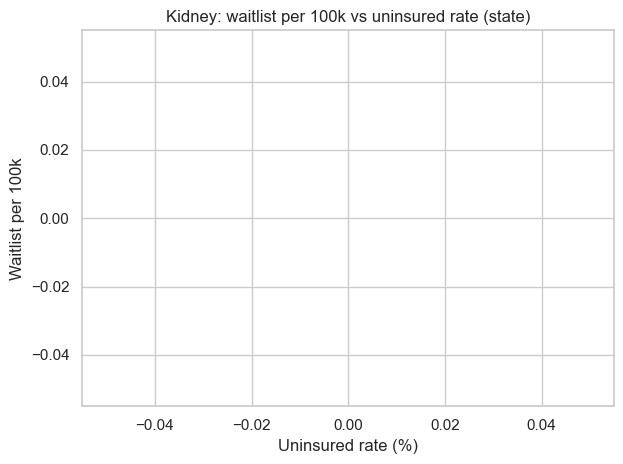

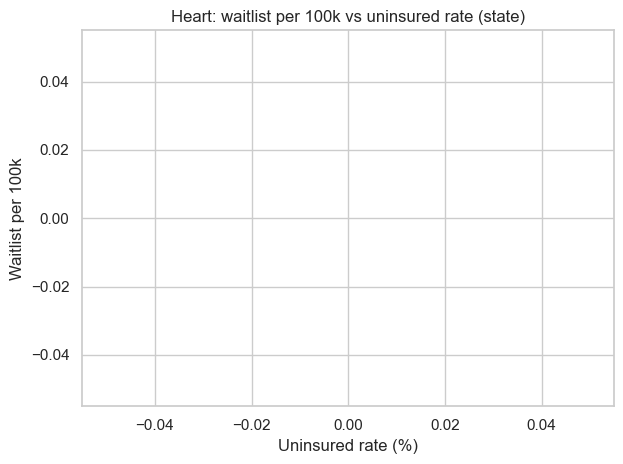

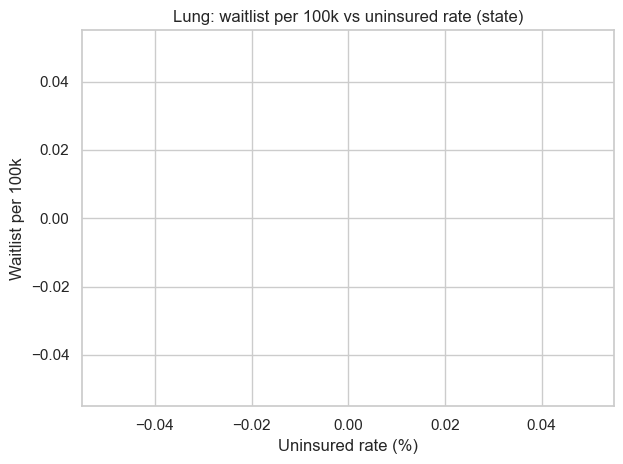

In [54]:
def scatter_uninsured(organ_name):
    sub = master_state[master_state["organ"].str.contains(organ_name, case=False, na=False)].copy()
    sub = sub.dropna(subset=["uninsured_share","waitlist_per_100k"])
    plt.figure()
    plt.scatter(sub["uninsured_share"]*100, sub["waitlist_per_100k"])
    plt.title(f"{organ_name}: waitlist per 100k vs uninsured rate (state)")
    plt.xlabel("Uninsured rate (%)")
    plt.ylabel("Waitlist per 100k")
    plt.tight_layout()
    plt.show()

for organ_name in ["Kidney","Heart","Lung"]:
    scatter_uninsured(organ_name)

Correlation (quick numeric summary)

In [55]:
for organ_name in ["Kidney","Heart","Lung"]:
    sub = master_state[master_state["organ"].str.contains(organ_name, case=False, na=False)].copy()
    sub = sub.dropna(subset=["uninsured_share","waitlist_per_100k"])
    corr = sub["uninsured_share"].corr(sub["waitlist_per_100k"])
    print(organ_name, "corr(uninsured_share, waitlist_per_100k) =", corr)

Kidney corr(uninsured_share, waitlist_per_100k) = nan
Heart corr(uninsured_share, waitlist_per_100k) = nan
Lung corr(uninsured_share, waitlist_per_100k) = nan


Supporting Question 4
Are outcome measures unevenly distributed?

In [60]:
cdc_state = cdc[cdc["breakdown"].astype(str).str.lower().eq("state")].copy()
cdc_state["state"] = cdc_state["category"].astype(str).str.strip()

# find crude rate column robustly
crude_col = next((c for c in cdc_state.columns if "crude" in c and "rate" in c), None)
cdc_state = cdc_state[["state", crude_col]].rename(columns={crude_col: "mortality_crude_rate"})

master_state2 = master_state.merge(cdc_state, on="state", how="left")

In [ ]:
Scatter: mortality crude rate vs waitlist per 100k

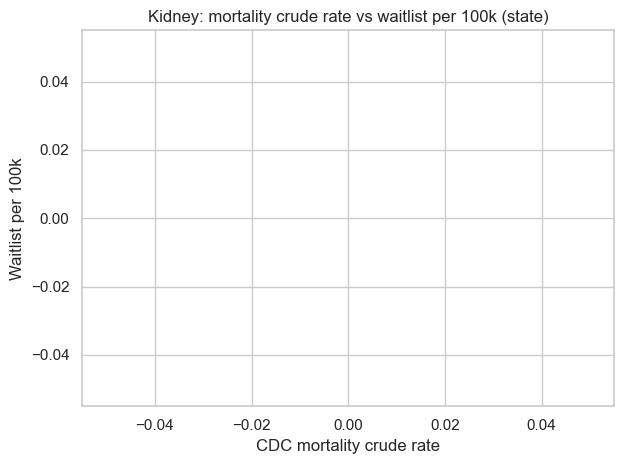

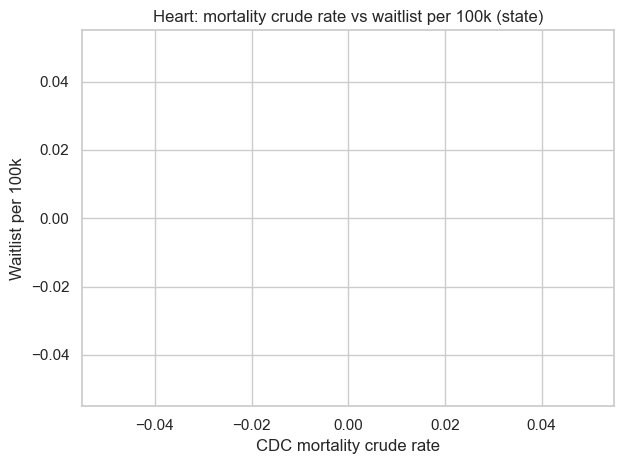

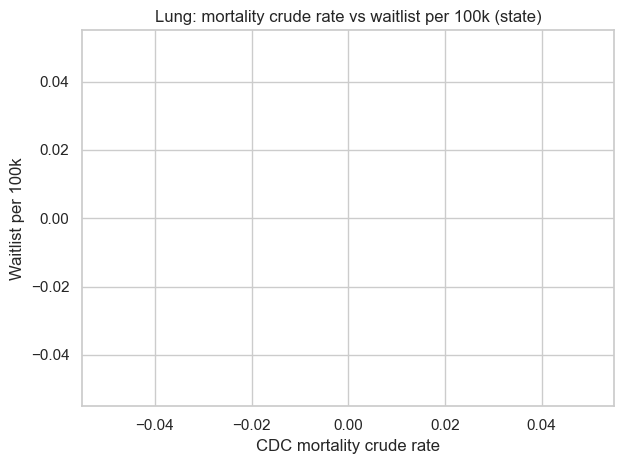

In [61]:
def scatter_mortality(organ_name):
    sub = master_state2[master_state2["organ"].str.contains(organ_name, case=False, na=False)].copy()
    sub = sub.dropna(subset=["mortality_crude_rate","waitlist_per_100k"])
    plt.figure()
    plt.scatter(sub["mortality_crude_rate"], sub["waitlist_per_100k"])
    plt.title(f"{organ_name}: mortality crude rate vs waitlist per 100k (state)")
    plt.xlabel("CDC mortality crude rate")
    plt.ylabel("Waitlist per 100k")
    plt.tight_layout()
    plt.show()

for organ_name in ["Kidney","Heart","Lung"]:
    scatter_mortality(organ_name)

CDC mortality trend by year (context)

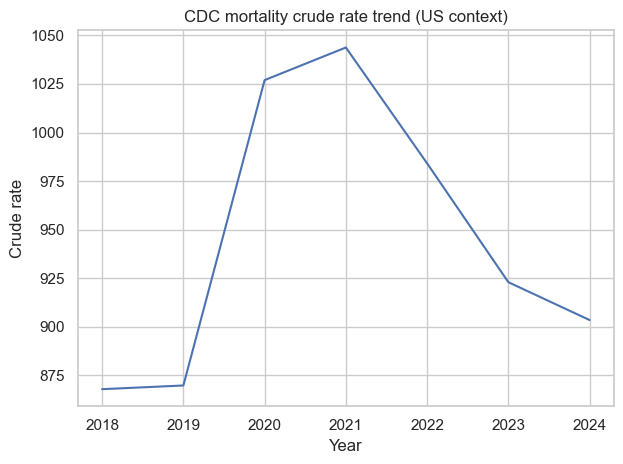

In [62]:
cdc_year = cdc[cdc["breakdown"].astype(str).str.lower().eq("year")].copy()
cdc_year["year_num"] = pd.to_numeric(cdc_year["category"], errors="coerce")
cdc_year = cdc_year.dropna(subset=["year_num"])
crude_col = next((c for c in cdc_year.columns if "crude" in c and "rate" in c), None)

plt.figure()
plt.plot(cdc_year["year_num"], cdc_year[crude_col])
plt.title("CDC mortality crude rate trend (US context)")
plt.xlabel("Year"); plt.ylabel("Crude rate")
plt.tight_layout()
plt.show()

Transplants over time (national)

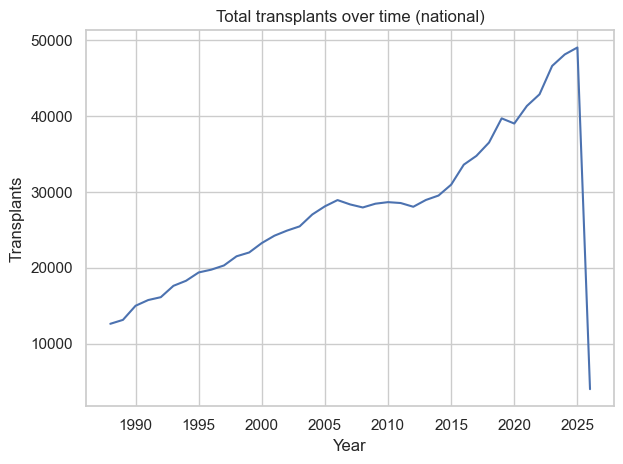

In [64]:
plt.figure()
plt.plot(unos_tx["year"], unos_tx["all_recipient_ages"])
plt.title("Total transplants over time (national)")
plt.xlabel("Year"); plt.ylabel("Transplants")
plt.tight_layout(); plt.show()

Estimated mean wait days by organ

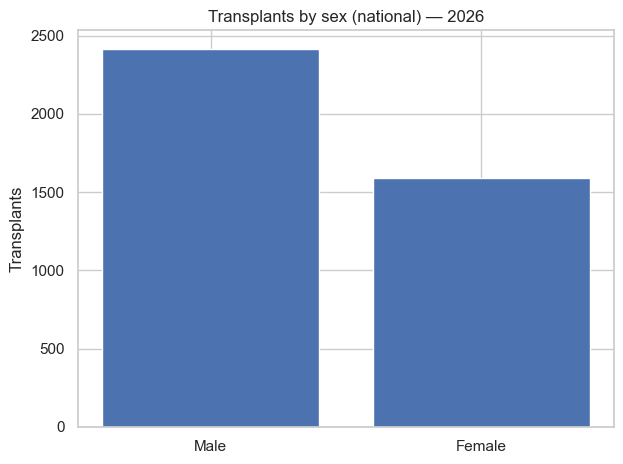

In [30]:

latest = tx["Year"].max()
row = tx.loc[tx["Year"] == latest].iloc[0]

sex_counts = pd.Series({"Male": row["Male"], "Female": row["Female"]}).dropna()

plt.figure()
plt.bar(sex_counts.index, sex_counts.values)
plt.title(f"Transplants by sex (national) — {latest}")
plt.ylabel("Transplants")
plt.tight_layout()
plt.show()

In [57]:
plot = wt_metrics.sort_values("est_mean_wait_days", ascending=False)

plt.figure()
plt.bar(plot["organ"], plot["est_mean_wait_days"])
plt.title("Estimated mean wait days by organ (from wait bins)")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Days (estimated)")
plt.tight_layout()
plt.show()

NameError: name 'wt_metrics' is not defined

SES vs waitlist burden (scatter)

In [28]:
sub = master_state[master_state["organ"].str.contains("heart", case=False, na=False)].copy()
sub = sub.dropna(subset=["Median_Income","waitlist_per_100k"])

plt.figure()
plt.scatter(sub["Median_Income"], sub["waitlist_per_100k"])
plt.title("Kidney waitlist burden vs median income (state)")
plt.xlabel("Median household income"); plt.ylabel("Waitlist per 100k")
plt.tight_layout(); plt.show()

NameError: name 'master_state' is not defined

C:\Users\boame\AppData\Local\Temp\ipykernel_38044\3017109877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


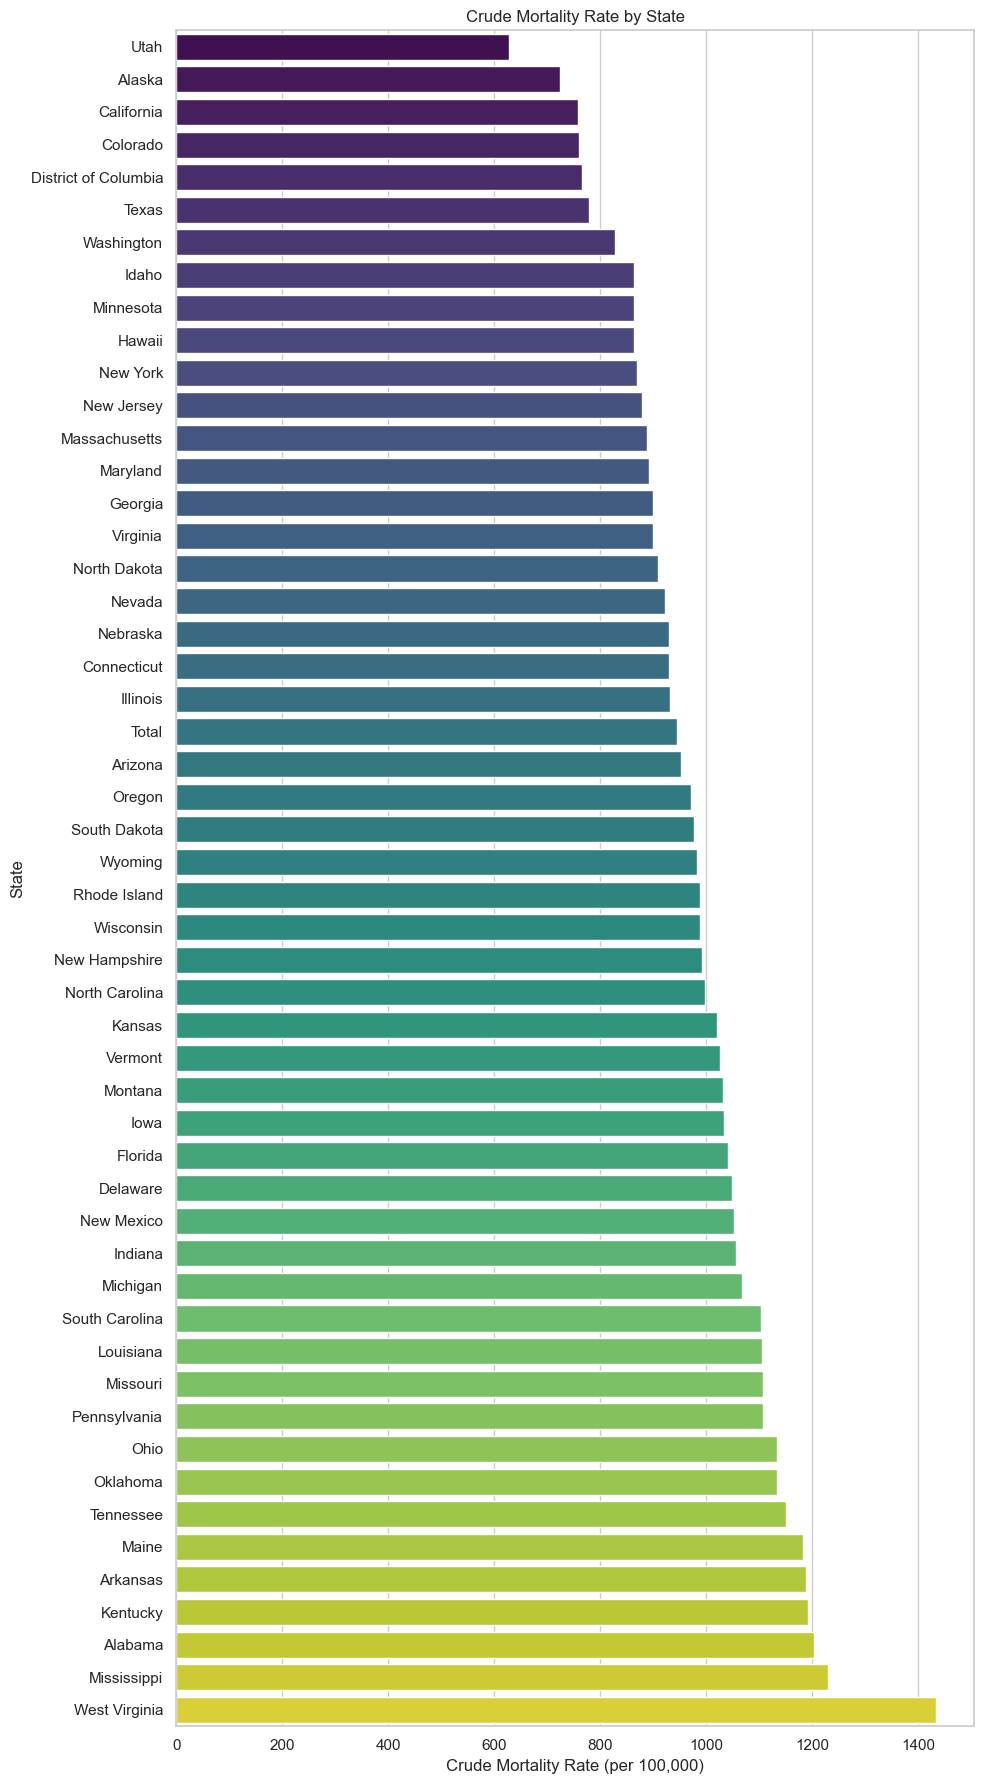

In [27]:
plt.figure(figsize=(10, 18))
cdc_state_sorted = cdc_state.sort_values("mortality_crude_rate", ascending=True)

sns.barplot(
    data=cdc_state_sorted,
    x="mortality_crude_rate",
    y="state",
    palette="viridis"
)

plt.title("Crude Mortality Rate by State")
plt.xlabel("Crude Mortality Rate (per 100,000)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


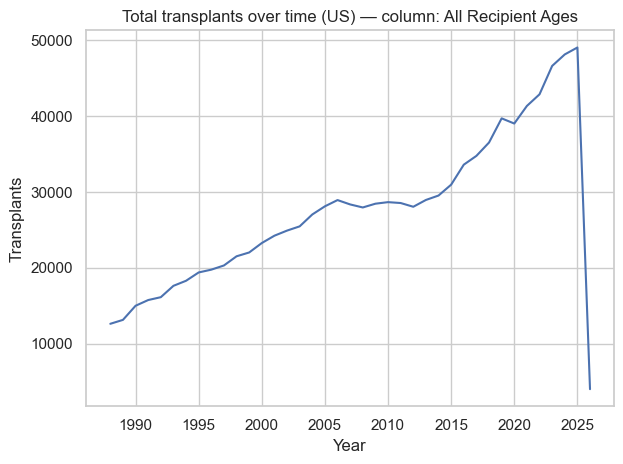

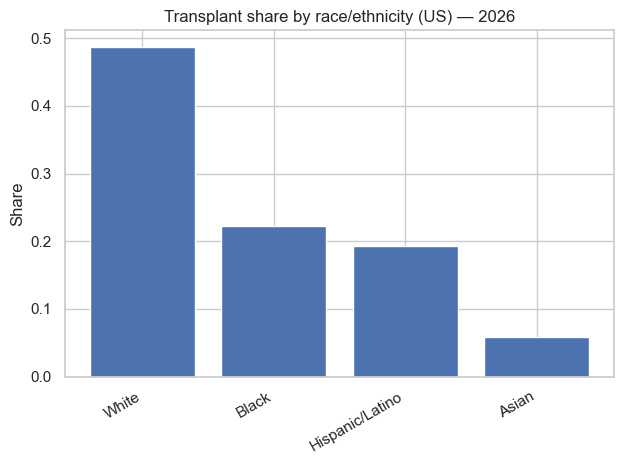

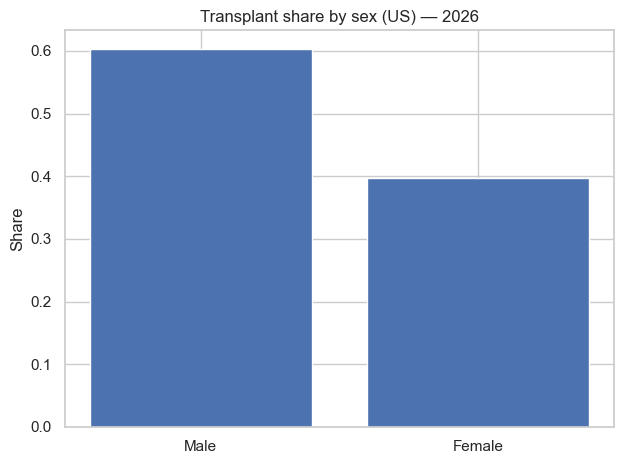

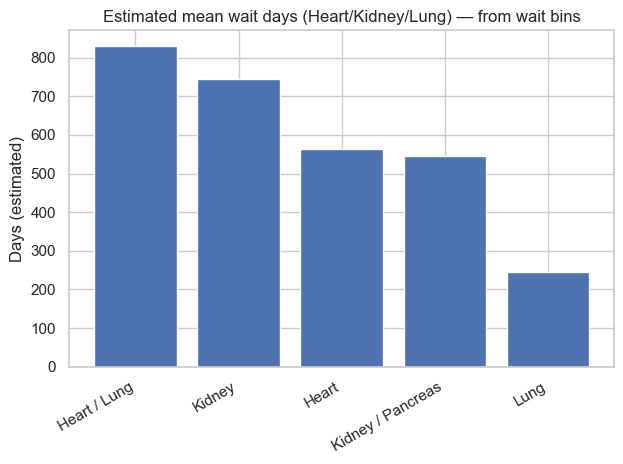

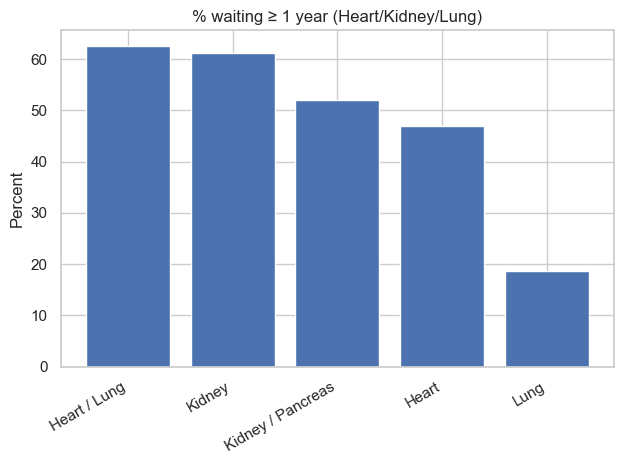

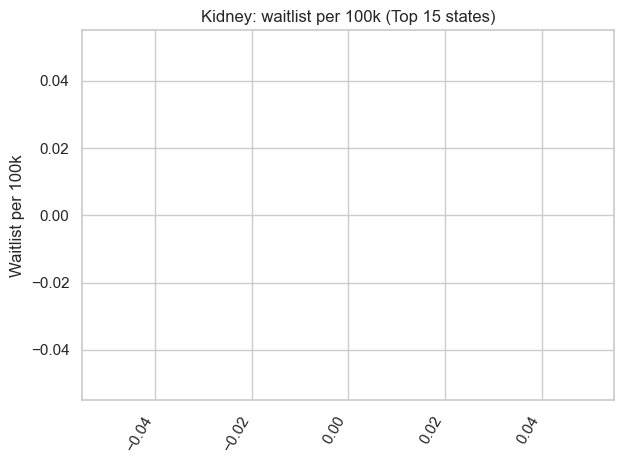

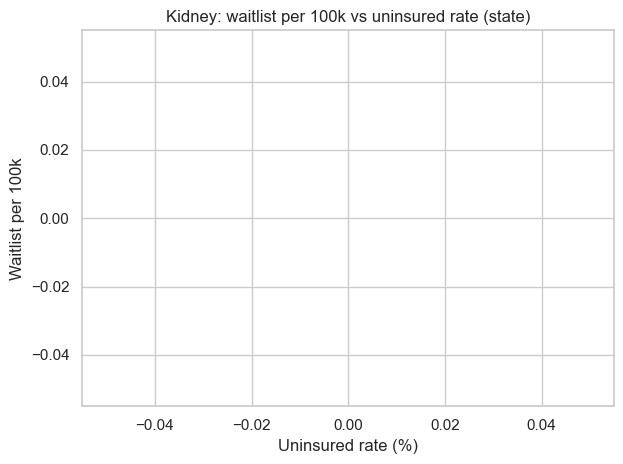

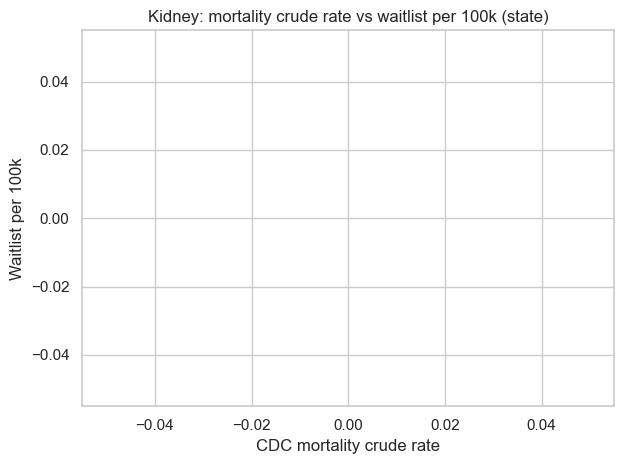

Saved charts to: C:\Users\boame\Documents\NSS\Capstone-DA16\Notebook\outputs\figures
Files: ['01_transplants_over_time.png', '02_transplant_share_by_race_latest.png', '03_transplant_share_by_sex_latest.png', '04_est_mean_wait_days_focus_organs.png', '05_pct_wait_1y_plus_focus_organs.png', '06_kidney_waitlist_per_100k_top15_states.png', '07_kidney_uninsured_vs_waitlist.png', '08_kidney_mortality_vs_waitlist.png']


In [72]:

# ----------------------------
# 0) Paths (edit BASE if needed)
# ----------------------------
BASE = Path(".")  # change if your files are in another folder, e.g. Path("data_clean")
OUT = Path("outputs/figures")
OUT.mkdir(parents=True, exist_ok=True)

FILES = {
    "tx": "unos_transplant.csv",
    "wl": "uno_waitlist.csv",
    "wt": "Can+Reg_Organ_by_Waiting_Time.csv",
    "census": "census_cleaned.csv",
    "cdc": "CDC_MORTALITY_cleaned_joined_long.csv",
}

def load_csv(name):
    path = BASE / FILES[name]
    if not path.exists():
        # fallback: try /mnt/data style path if running in that environment
        alt = Path("/mnt/data") / FILES[name]
        if alt.exists():
            path = alt
        else:
            raise FileNotFoundError(f"Could not find {FILES[name]} in {BASE} or /mnt/data")
    return pd.read_csv(path, dtype=str)

def to_num(s):
    return pd.to_numeric(s.astype(str).str.replace(",", "", regex=False), errors="coerce")

def save_show(fig_name):
    plt.tight_layout()
    plt.savefig(OUT / fig_name, dpi=200)
    plt.show()

def pick_col(cols, candidates):
    # return first candidate that exists in cols
    for c in candidates:
        if c in cols:
            return c
    return None

# ----------------------------
# 1) Load datasets
# ----------------------------
tx = load_csv("tx")
wl = load_csv("wl")
wt = load_csv("wt")
census = load_csv("census")
cdc = load_csv("cdc")

# ----------------------------
# 2) Clean TRANSPLANTS (tx)
# ----------------------------
tx.columns = tx.columns.str.strip()
year_col = pick_col(tx.columns, ["Year", "year"])
if year_col is None:
    raise ValueError("Could not find a Year column in unos_transplant.csv")

tx = tx[tx[year_col].astype(str).str.fullmatch(r"\d{4}", na=False)].copy()
tx[year_col] = pd.to_numeric(tx[year_col], errors="coerce").astype("Int64")

# numeric conversion for all other columns
for c in tx.columns:
    if c != year_col:
        tx[c] = to_num(tx[c])

# pick a "total transplants" column
total_tx_col = pick_col(tx.columns, [
    "All Recipient Ages", "All Recipients", "All Organs", "Total", "Transplants"
])
if total_tx_col is None:
    # fallback: choose the numeric column with largest mean
    num_candidates = [c for c in tx.columns if c != year_col]
    total_tx_col = max(num_candidates, key=lambda c: tx[c].mean(skipna=True))

latest_year = int(tx[year_col].max())
tx_latest = tx.loc[tx[year_col] == latest_year].iloc[0]

# ----------------------------
# 3) Clean WAITLIST (wl) + build state-long + merge census
# ----------------------------
wl.columns = wl.columns.str.strip()
wl["Candidates"] = wl["Candidates"].astype(str).str.strip()

# Identify state columns
if "States" in wl.columns:
    state_start = wl.columns.tolist().index("States") + 1
    state_cols = wl.columns.tolist()[state_start:]
else:
    # fallback: detect state columns by intersection with a known set
    US_STATES = {
        "Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut","Delaware",
        "District of Columbia","Florida","Georgia","Hawaii","Idaho","Illinois","Indiana","Iowa",
        "Kansas","Kentucky","Louisiana","Maine","Maryland","Massachusetts","Michigan","Minnesota",
        "Mississippi","Missouri","Montana","Nebraska","Nevada","New Hampshire","New Jersey",
        "New Mexico","New York","North Carolina","North Dakota","Ohio","Oklahoma","Oregon",
        "Pennsylvania","Rhode Island","South Carolina","South Dakota","Tennessee","Texas","Utah",
        "Vermont","Virginia","Washington","West Virginia","Wisconsin","Wyoming","Puerto Rico"
    }
    state_cols = [c for c in wl.columns if c in US_STATES]

wl_state = wl[["Candidates"] + state_cols].copy()
for c in state_cols:
    wl_state[c] = to_num(wl_state[c])

wl_state_long = wl_state.melt(
    id_vars="Candidates", var_name="state", value_name="waitlist_count"
).rename(columns={"Candidates": "organ"})

# Clean census
census.columns = census.columns.str.strip().str.lower()
# Expect: name, tot_pop, median_income, poverty_rate, uninsured_rate, uninsured_share, poverty_share
if "name" not in census.columns:
    raise ValueError("census_cleaned.csv must have a 'name' column for state names")

for c in ["tot_pop","median_income","poverty_rate","uninsured_rate","uninsured_share","poverty_share"]:
    if c in census.columns:
        census[c] = to_num(census[c])

# If shares are missing, compute from counts
if "uninsured_share" not in census.columns and ("uninsured_rate" in census.columns and "tot_pop" in census.columns):
    census["uninsured_share"] = census["uninsured_rate"] / census["tot_pop"]
if "poverty_share" not in census.columns and ("poverty_rate" in census.columns and "tot_pop" in census.columns):
    census["poverty_share"] = census["poverty_rate"] / census["tot_pop"]

master_state = wl_state_long.merge(
    census[["name","tot_pop","median_income","uninsured_share","poverty_share"]],
    left_on="state", right_on="name", how="left"
).drop(columns=["name"])

master_state["waitlist_per_100k"] = (master_state["waitlist_count"] / master_state["tot_pop"]) * 100000

# ----------------------------
# 4) Clean WAIT-TIME bins (wt) and compute metrics
# ----------------------------
wt.columns = wt.columns.str.strip()
organ_col = pick_col(wt.columns, ["Cand+Reg", "Cand_Reg", "organ", "Candidates"])
if organ_col is None:
    organ_col = wt.columns[0]  # fallback
wt = wt.rename(columns={organ_col: "organ"})
wt["organ"] = wt["organ"].astype(str).str.strip()

bins = ["< 30 Days","30 to < 90 Days","90 Days to < 6 Months","6 Months to < 1 Year",
        "1 Year to < 2 Years","2 Years to < 3 Years","3 Years to < 5 Years","5 or More Years"]
for b in bins:
    if b in wt.columns:
        wt[b] = to_num(wt[b])
    else:
        raise ValueError(f"Missing wait bin column: {b}")

wt["total_waiting"] = wt[bins].sum(axis=1)

midpoints = {
    "< 30 Days": 15,
    "30 to < 90 Days": 60,
    "90 Days to < 6 Months": 135,
    "6 Months to < 1 Year": 270,
    "1 Year to < 2 Years": 547.5,
    "2 Years to < 3 Years": 912.5,
    "3 Years to < 5 Years": 1460,
    "5 or More Years": 2190,   # assumption (~6 years)
}
wt["est_mean_wait_days"] = sum(wt[b]*midpoints[b] for b in bins) / wt["total_waiting"]
wt["pct_wait_1y_plus"] = (wt["1 Year to < 2 Years"] + wt["2 Years to < 3 Years"] +
                          wt["3 Years to < 5 Years"] + wt["5 or More Years"]) / wt["total_waiting"]
wt["pct_wait_5y_plus"] = wt["5 or More Years"] / wt["total_waiting"]

# Filter to your focus organs
FOCUS = ["Heart", "Kidney", "Lung"]
wt_focus = wt[wt["organ"].str.contains("|".join(FOCUS), case=False, na=False)].copy()

# ----------------------------
# 5) Clean CDC mortality (state crude rate) for context
# ----------------------------
cdc.columns = (cdc.columns.str.strip()
               .str.lower()
               .str.replace(r"[^a-z0-9]+","_", regex=True))

for c in ["deaths","population","crude_rate"]:
    if c in cdc.columns:
        cdc[c] = to_num(cdc[c])

cdc_state = cdc[cdc["breakdown"].astype(str).str.lower().eq("state")].copy()
cdc_state["state"] = cdc_state["category"].astype(str).str.strip()

# detect crude rate col (sometimes it might not be exactly 'crude_rate')
crude_col = pick_col(cdc_state.columns, ["crude_rate"])
if crude_col is None:
    crude_col = next((c for c in cdc_state.columns if "crude" in c and "rate" in c), None)
cdc_state = cdc_state[["state", crude_col]].rename(columns={crude_col: "mortality_crude_rate"})

master_state2 = master_state.merge(cdc_state, on="state", how="left")

# ----------------------------
# 6) FINAL SLIDE CHARTS (8 charts)
# ----------------------------

# Chart 1: Total transplants over time (national)
plt.figure()
plt.plot(tx[year_col], tx[total_tx_col])
plt.title(f"Total transplants over time (US) — column: {total_tx_col}")
plt.xlabel("Year"); plt.ylabel("Transplants")
save_show("01_transplants_over_time.png")

# Chart 2: Transplant share by race (latest year) — fallback to waitlist if tx lacks race cols
race_candidates_tx = ["White", "Black", "Hispanic/Latino", "Hispanic", "Asian"]
race_cols_tx = [c for c in race_candidates_tx if c in tx.columns]

if len(race_cols_tx) >= 2:
    race_vals = pd.Series({c: float(tx_latest[c]) for c in race_cols_tx})
    race_share = race_vals / float(tx_latest[total_tx_col])
    plt.figure()
    plt.bar(race_share.index, race_share.values)
    plt.title(f"Transplant share by race/ethnicity (US) — {latest_year}")
    plt.ylabel("Share")
    plt.xticks(rotation=30, ha="right")
    save_show("02_transplant_share_by_race_latest.png")
else:
    # fallback: use waitlist snapshot (All Organs row)
    wl_all = wl[wl["Candidates"].eq("All Organs")].iloc[0]
    wait_race_cols = [c for c in ["White","Black","Hispanic","Asian"] if c in wl.columns]
    wait_vals = pd.Series({c: float(to_num(pd.Series([wl_all[c]])).iloc[0]) for c in wait_race_cols})
    wait_share = wait_vals / wait_vals.sum()
    plt.figure()
    plt.bar(wait_share.index, wait_share.values)
    plt.title("Waitlist share by race/ethnicity (snapshot) — All Organs")
    plt.ylabel("Share")
    plt.xticks(rotation=30, ha="right")
    save_show("02_waitlist_share_by_race_snapshot.png")

# Chart 3: Transplants by sex (latest year) — fallback to waitlist if tx lacks sex cols
sex_cols_tx = [c for c in ["Male","Female"] if c in tx.columns]
if len(sex_cols_tx) == 2:
    sex_vals = pd.Series({c: float(tx_latest[c]) for c in sex_cols_tx})
    sex_share = sex_vals / sex_vals.sum()
    plt.figure()
    plt.bar(sex_share.index, sex_share.values)
    plt.title(f"Transplant share by sex (US) — {latest_year}")
    plt.ylabel("Share")
    save_show("03_transplant_share_by_sex_latest.png")
else:
    wl_all = wl[wl["Candidates"].eq("All Organs")].iloc[0]
    wait_sex_cols = [c for c in ["Male","Female"] if c in wl.columns]
    wait_vals = pd.Series({c: float(to_num(pd.Series([wl_all[c]])).iloc[0]) for c in wait_sex_cols})
    wait_share = wait_vals / wait_vals.sum()
    plt.figure()
    plt.bar(wait_share.index, wait_share.values)
    plt.title("Waitlist share by sex (snapshot) — All Organs")
    plt.ylabel("Share")
    save_show("03_waitlist_share_by_sex_snapshot.png")

# Chart 4: Estimated mean wait days (Heart/Kidney/Lung)
plot = wt_focus.sort_values("est_mean_wait_days", ascending=False)
plt.figure()
plt.bar(plot["organ"], plot["est_mean_wait_days"])
plt.title("Estimated mean wait days (Heart/Kidney/Lung) — from wait bins")
plt.ylabel("Days (estimated)")
plt.xticks(rotation=30, ha="right")
save_show("04_est_mean_wait_days_focus_organs.png")

# Chart 5: % waiting >= 1 year (Heart/Kidney/Lung)
plot = wt_focus.sort_values("pct_wait_1y_plus", ascending=False)
plt.figure()
plt.bar(plot["organ"], plot["pct_wait_1y_plus"]*100)
plt.title("% waiting ≥ 1 year (Heart/Kidney/Lung)")
plt.ylabel("Percent")
plt.xticks(rotation=30, ha="right")
save_show("05_pct_wait_1y_plus_focus_organs.png")

# Chart 6: Kidney waitlist per 100k — Top 15 states
kidney = master_state[master_state["organ"].str.contains("Kidney", case=False, na=False)].copy()
kidney = kidney.dropna(subset=["waitlist_per_100k"]).sort_values("waitlist_per_100k", ascending=False).head(15)
plt.figure()
plt.bar(kidney["state"], kidney["waitlist_per_100k"])
plt.title("Kidney: waitlist per 100k (Top 15 states)")
plt.ylabel("Waitlist per 100k")
plt.xticks(rotation=60, ha="right")
save_show("06_kidney_waitlist_per_100k_top15_states.png")

# Chart 7: Kidney waitlist per 100k vs uninsured rate
kidney_sc = master_state[master_state["organ"].str.contains("Kidney", case=False, na=False)].copy()
kidney_sc = kidney_sc.dropna(subset=["uninsured_share","waitlist_per_100k"])
plt.figure()
plt.scatter(kidney_sc["uninsured_share"]*100, kidney_sc["waitlist_per_100k"])
plt.title("Kidney: waitlist per 100k vs uninsured rate (state)")
plt.xlabel("Uninsured rate (%)")
plt.ylabel("Waitlist per 100k")
save_show("07_kidney_uninsured_vs_waitlist.png")

# Chart 8: Kidney waitlist per 100k vs CDC mortality crude rate (context)
kidney_m = master_state2[master_state2["organ"].str.contains("Kidney", case=False, na=False)].copy()
kidney_m = kidney_m.dropna(subset=["mortality_crude_rate","waitlist_per_100k"])
plt.figure()
plt.scatter(kidney_m["mortality_crude_rate"], kidney_m["waitlist_per_100k"])
plt.title("Kidney: mortality crude rate vs waitlist per 100k (state)")
plt.xlabel("CDC mortality crude rate")
plt.ylabel("Waitlist per 100k")
save_show("08_kidney_mortality_vs_waitlist.png")

print("Saved charts to:", OUT.resolve())
print("Files:", sorted([p.name for p in OUT.glob("*.png")]))

In [74]:
wl.columns.tolist()[:25]

['Candidates',
 'All Organs',
 'Kidney',
 'Liver',
 'Pancreas',
 'Kidney / Pancreas',
 'Heart',
 'Lung',
 'Heart / Lung',
 'Intestine',
 'All Organs.1',
 'Kidney.1',
 'Liver.1',
 'Pancreas.1',
 'Kidney / Pancreas.1',
 'Heart.1',
 'Lung.1',
 'Heart / Lung.1',
 'Intestine.1']